# Multi-Class Genomic Knowledge Distillation: Unlocking Dark Knowledge

Binary classification soft labels carry ~1 bit of dark knowledge (vs ~6.6 bits for 100 classes), which explains why logit-only KD showed ~0% gain on binary promoter classification. This notebook creates a **5-class regulatory element classification** task where teacher soft labels become genuinely informative, and standard logit KD should show clear gains.

**Classes:** Promoter (TATA), Promoter (no TATA), Enhancer, Splice Donor, Splice Acceptor

**Setup:** Set GPU T4 x 2, enable internet.

In [1]:
!pip install transformers datasets accelerate scikit-learn einops

# Configuration & Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import gc
import os
import json
import time
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BertConfig,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    TrainerCallback,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import load_dataset, Dataset, concatenate_datasets
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ===== Configurable Constants =====
MODEL_NAME = "quietflamingo/dnabert2-no-flashattention"
NUM_CLASSES = 5
TEACHER_EPOCHS = 5
MAX_LENGTH = 300
BATCH_SIZE = 16
NUM_EPOCHS = 10
ALPHA = 0.5        # Distillation: weight for hard loss
TEMPERATURE = 3.0  # Distillation: softmax temperature
SEED = 42

# ===== Reproducibility =====
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ===== GPU Info =====
device = "cuda" if torch.cuda.is_available() else "cpu"
num_gpus = torch.cuda.device_count()
print(f"Device: {device}")
print(f"Number of GPUs: {num_gpus}")
for i in range(num_gpus):
    name = torch.cuda.get_device_name(i)
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {name} ({mem:.1f} GB)")

Device: cuda
Number of GPUs: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


# Load & Construct Multi-Class Dataset

In [3]:
# Load full InstaDeepAI dataset
print("Loading InstaDeepAI nucleotide transformer downstream tasks...")
raw_dataset = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks")

# Define task-to-class mapping (positive samples only from each binary task)
TASK_CLASS_MAP = {
    "promoter_tata": 0,
    "promoter_no_tata": 1,
    "enhancers": 2,
    "splice_sites_donors": 3,
    "splice_sites_acceptors": 4,
}
CLASS_NAMES = ["Promoter (TATA)", "Promoter (no TATA)", "Enhancer", "Splice Donor", "Splice Acceptor"]

def collect_positives(split_data, task_name, new_label):
    """Filter for a specific task and keep only positive samples (label==1), relabeled."""
    filtered = split_data.filter(lambda ex: ex["task"] == task_name and ex["label"] == 1)
    # Relabel with the new multi-class label
    filtered = filtered.map(lambda ex: {"sequence": ex["sequence"].upper(), "label": new_label})
    return filtered

# Collect positives for each class from train and test splits
train_parts = []
test_parts = []
for task_name, class_id in TASK_CLASS_MAP.items():
    tr = collect_positives(raw_dataset["train"], task_name, class_id)
    te = collect_positives(raw_dataset["test"], task_name, class_id)
    print(f"  {task_name}: train={len(tr)}, test={len(te)}")
    train_parts.append(tr)
    test_parts.append(te)

# Undersample all classes to match the smallest class size (balanced dataset)
min_train = min(len(p) for p in train_parts)
min_test = min(len(p) for p in test_parts)
print(f"\nUndersampling to: train={min_train}/class, test={min_test}/class")

balanced_train_parts = []
balanced_test_parts = []
for i, (tr, te) in enumerate(zip(train_parts, test_parts)):
    tr_balanced = tr.shuffle(seed=SEED).select(range(min(min_train, len(tr))))
    te_balanced = te.shuffle(seed=SEED).select(range(min(min_test, len(te))))
    balanced_train_parts.append(tr_balanced)
    balanced_test_parts.append(te_balanced)

train_data = concatenate_datasets(balanced_train_parts).shuffle(seed=SEED)
test_data = concatenate_datasets(balanced_test_parts).shuffle(seed=SEED)

print(f"\nFinal dataset: train={len(train_data)}, test={len(test_data)}")
print("Per-class counts (train):")
for class_id, class_name in enumerate(CLASS_NAMES):
    count = sum(1 for ex in train_data if ex["label"] == class_id)
    print(f"  {class_id}: {class_name} = {count}")

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

def tokenize_func(examples):
    return tokenizer(examples["sequence"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

print(f"\nTokenizing with max_length={MAX_LENGTH}...")
tokenized_train = train_data.map(tokenize_func, batched=True)
tokenized_test = test_data.map(tokenize_func, batched=True)

# Set format for PyTorch
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

train_dataset = tokenized_train
eval_dataset = tokenized_test

print(f"Tokenization complete!")
print(f"Train columns: {train_dataset.column_names}")
print(f"Sample input_ids shape: {train_dataset[0]['input_ids'].shape}")

Loading InstaDeepAI nucleotide transformer downstream tasks...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

H3K14ac/train.parquet:   0%|          | 0.00/7.70M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing with max_length=300...


Map:   0%|          | 0/13665 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization complete!
Train columns: ['sequence', 'name', 'labels', 'task', 'input_ids', 'attention_mask']
Sample input_ids shape: torch.Size([300])


# Train Multi-Class Teacher

In [4]:
# ===== MULTI-CLASS METRICS =====
def compute_metrics_multiclass(pred):
    labels = pred.label_ids
    logits = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }


# ===== PROGRESS CALLBACK =====
class ProgressCallback(TrainerCallback):
    """Custom callback to force print output in Kaggle"""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            print(f"Step {state.global_step}: {logs}", flush=True)

    def on_epoch_begin(self, args, state, control, **kwargs):
        print(f"\n{'='*60}", flush=True)
        print(f"Starting Epoch {int(state.epoch) + 1}/{args.num_train_epochs}", flush=True)
        print(f"{'='*60}", flush=True)

    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"Epoch {int(state.epoch)} completed!", flush=True)


# ===== FINE-TUNE DNABERT-2 AS 5-CLASS TEACHER =====
print("Loading DNABERT-2 for 5-class fine-tuning...")

from transformers import AutoConfig
from transformers.dynamic_module_utils import get_class_from_dynamic_module
from safetensors.torch import load_file as load_safetensors
from huggingface_hub import hf_hub_download

# Load config and patch required fields
config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
config.num_labels = NUM_CLASSES
config.pad_token_id = tokenizer.pad_token_id  # DNABERT-2 BertEmbeddings requires this

# Get DNABERT-2's custom model class from its auto_map
# (bypasses from_pretrained's meta-device context that breaks ALiBi tensor math)
class_ref = config.auto_map["AutoModelForSequenceClassification"]
model_class = get_class_from_dynamic_module(class_ref, MODEL_NAME)

# Direct instantiation on CPU — no meta device wrapping
teacher_model = model_class(config)

import torch

# 1. Download the correct filename (pytorch_model.bin) for this specific repo
print(f"Downloading weights for {MODEL_NAME}...")
weights_path = hf_hub_download(MODEL_NAME, filename="pytorch_model.bin")

# 2. Load using torch.load (required for .bin files)
pretrained_state = torch.load(weights_path, map_location="cpu")

# 3. Load into the model
# strict=False allows the new 5-class head to be randomly initialized
missing, unexpected = teacher_model.load_state_dict(pretrained_state, strict=False)

print(f"Loaded pretrained weights successfully!")
print(f"- Missing (randomly initialized): {len(missing)}")
print(f"- Unexpected (ignored): {len(unexpected)}")

# 4. Move to GPU
teacher_model.to(device)
# --------------------------------------------

teacher_params = sum(p.numel() for p in teacher_model.parameters())
print(f"Teacher parameters: {teacher_params:,} ({teacher_params/1e6:.1f}M)")

teacher_args = TrainingArguments(
    output_dir="/kaggle/working/multiclass_teacher",
    num_train_epochs=TEACHER_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    fp16=True,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    learning_rate=2e-5,
)

teacher_trainer = Trainer(
    model=teacher_model,
    args=teacher_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_multiclass,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        ProgressCallback(),
    ],
)

print("Starting teacher training...")
start_time = time.time()
teacher_trainer.train()
teacher_train_time = time.time() - start_time

# Evaluate teacher
teacher_metrics = teacher_trainer.evaluate()
print(f"\n--- Teacher Results ---")
print(f"  Accuracy:    {teacher_metrics['eval_accuracy']:.2%}")
print(f"  F1 (macro):  {teacher_metrics['eval_f1_macro']:.4f}")
print(f"  F1 (weighted): {teacher_metrics['eval_f1_weighted']:.4f}")
print(f"  Time:        {teacher_train_time/60:.1f} min")

# Save and set to eval mode
teacher_model.save_pretrained("/kaggle/working/multiclass_teacher_final")
teacher_model.eval()
print("Teacher model saved and set to eval mode.")

# Cleanup trainer
del teacher_trainer
gc.collect()
torch.cuda.empty_cache()

Loading DNABERT-2 for 5-class fine-tuning...


bert_layers.py: 0.00B [00:00, ?B/s]

bert_padding.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_layers.py
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/468M [00:00<?, ?B/s]

...

Step 2140: {'train_runtime': 1337.9795, 'train_samples_per_second': 51.066, 'train_steps_per_second': 1.599, 'total_flos': 1.4011081498125e+16, 'train_loss': 0.22649272758269978, 'epoch': 5.0}


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 2140: {'eval_loss': 0.1341201215982437, 'eval_accuracy': 0.966, 'eval_f1_macro': 0.9659805731628494, 'eval_f1_weighted': 0.9659805731628492, 'eval_runtime': 8.0064, 'eval_samples_per_second': 124.901, 'eval_steps_per_second': 3.997, 'epoch': 5.0}

--- Teacher Results ---
  Accuracy:    96.60%
  F1 (macro):  0.9660
  F1 (weighted): 0.9660
  Time:        22.3 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Teacher model saved and set to eval mode.


# Model Definitions & Utilities

In [5]:
# ===== DISTILLATION TRAINER =====
class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, alpha=0.5, temperature=3.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model.to(self.args.device)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher_model.eval()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs_student = model(**inputs)
        student_logits = outputs_student.logits
        labels = inputs.get("labels")

        with torch.no_grad():
            outputs_teacher = self.teacher_model(**inputs)
            teacher_logits = outputs_teacher.logits

        soft_loss = nn.KLDivLoss(reduction="batchmean")(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        hard_loss = F.cross_entropy(student_logits, labels)

        loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss

        return (loss, outputs_student) if return_outputs else loss


# ===== HYBRID CNN-TRANSFORMER STUDENT (5-class) =====
class DNAHybridStudent(nn.Module):
    def __init__(self, layers=2):
        super().__init__()
        config = BertConfig.from_pretrained("quietflamingo/dnabert2-no-flashattention", num_hidden_layers=layers)
        config.pad_token_id = tokenizer.pad_token_id
        self.bert = BertForSequenceClassification(config).bert

        self.conv = nn.Conv1d(in_channels=768, out_channels=128, kernel_size=9, padding=4)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Linear(128, NUM_CLASSES)

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        x = sequence_output.permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)

        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)


# ===== HELPER: PURE TRANSFORMER STUDENT (5-class) =====
def get_pure_transformer(layers):
    config = BertConfig.from_pretrained(
        "quietflamingo/dnabert2-no-flashattention",
        num_hidden_layers=layers, num_labels=NUM_CLASSES,
    )
    config.pad_token_id = tokenizer.pad_token_id
    return BertForSequenceClassification(config)


# ===== PARAMETER COUNTING =====
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


print("All components defined successfully!")

All components defined successfully!


# Train Baseline & Distilled Students

In [6]:
# ===== 4 EXPERIMENTS: Baseline & KD for each architecture =====
experiments = [
    ("6-Layer-Baseline",  lambda: get_pure_transformer(6),    "baseline"),
    ("6-Layer-KD",        lambda: get_pure_transformer(6),    "kd"),
    ("Hybrid-Baseline",   lambda: DNAHybridStudent(layers=2), "baseline"),
    ("Hybrid-KD",         lambda: DNAHybridStudent(layers=2), "kd"),
]

all_results = {}

for exp_idx, (name, model_fn, mode) in enumerate(experiments):
    print(f"\n{'#'*70}")
    print(f"# Experiment {exp_idx+1}/{len(experiments)}: {name} ({mode})")
    print(f"{'#'*70}")

    gc.collect()
    torch.cuda.empty_cache()

    student_model = model_fn()
    student_params = count_parameters(student_model)
    is_hybrid = isinstance(student_model, DNAHybridStudent)
    print(f"Parameters: {student_params:,} ({student_params/1e6:.1f}M)")

    args = TrainingArguments(
        output_dir=f"/kaggle/working/{name}",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        fp16=True,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_accuracy",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        remove_unused_columns=not is_hybrid,
        warmup_ratio=0.1,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        learning_rate=2e-5,
    )

    start_time = time.time()

    if mode == "kd":
        trainer = DistillationTrainer(
            model=student_model,
            teacher_model=teacher_model,
            alpha=ALPHA,
            temperature=TEMPERATURE,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics_multiclass,
            callbacks=[
                EarlyStoppingCallback(early_stopping_patience=3),
                ProgressCallback(),
            ],
        )
    else:
        trainer = Trainer(
            model=student_model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            compute_metrics=compute_metrics_multiclass,
            callbacks=[
                EarlyStoppingCallback(early_stopping_patience=3),
                ProgressCallback(),
            ],
        )

    print(f"Starting training for {name}...", flush=True)
    trainer.train()
    train_time = time.time() - start_time

    metrics = trainer.evaluate()
    print(f"\n--- {name} Results ---")
    print(f"  Accuracy:      {metrics['eval_accuracy']:.2%}")
    print(f"  F1 (macro):    {metrics['eval_f1_macro']:.4f}")
    print(f"  F1 (weighted): {metrics['eval_f1_weighted']:.4f}")
    print(f"  Time:          {train_time/60:.1f} min")

    all_results[name] = {
        "accuracy": metrics["eval_accuracy"],
        "f1_macro": metrics["eval_f1_macro"],
        "f1_weighted": metrics["eval_f1_weighted"],
        "loss": metrics["eval_loss"],
        "params": student_params,
        "train_time_min": round(train_time / 60, 1),
        "mode": mode,
    }

    del trainer, student_model
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nAll experiments completed!")


######################################################################
# Experiment 1/4: 6-Layer-Baseline (baseline)
######################################################################


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Parameters: 46,663,685 (46.7M)
Starting training for 6-Layer-Baseline...

Starting Epoch 1/10


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.172704,1.122926,0.619000,0.539552,0.539552
2,1.108799,1.091279,0.656000,0.587151,0.587151
3,0.992346,1.027377,0.690000,0.618002,0.618002
4,0.862176,0.984530,0.720000,0.677996,0.677996
5,0.753987,1.098133,0.751000,0.741367,0.741367
6,0.725212,1.142845,0.716000,0.663676,0.663676
7,0.667703,1.235567,0.747000,0.743320,0.743320
8,0.664623,1.383791,0.747000,0.734272,0.734272


...

Step 3500: {'loss': 0.21078413009643554, 'grad_norm': 5.213663578033447, 'learning_rate': 1.9609462983156855e-06, 'epoch': 8.177570093457945}
Step 3600: {'loss': 0.2228244400024414, 'grad_norm': 5.5681233406066895, 'learning_rate': 1.503136625317595e-06, 'epoch': 8.411214953271028}
Step 3700: {'loss': 0.21416563034057617, 'grad_norm': 9.11868667602539, 'learning_rate': 1.1018135061984004e-06, 'epoch': 8.644859813084112}
Step 3800: {'loss': 0.20449254989624024, 'grad_norm': 9.109082221984863, 'learning_rate': 7.59644909006002e-07, 'epoch': 8.878504672897197}
Epoch 9 completed!
Step 3852: {'eval_loss': 0.6266785264015198, 'eval_accuracy': 0.868, 'eval_f1_macro': 0.867926207323715, 'eval_f1_weighted': 0.867926207323715, 'eval_runtime': 11.91, 'eval_samples_per_second': 83.963, 'eval_steps_per_second': 2.687, 'epoch': 9.0}

Starting Epoch 10/10


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 3900: {'loss': 0.1951972198486328, 'grad_norm': 5.880428314208984, 'learning_rate': 4.789055466607661e-07, 'epoch': 9.11214953271028}
Step 4000: {'loss': 0.20863792419433594, 'grad_norm': 6.137484073638916, 'learning_rate': 2.6146175482301027e-07, 'epoch': 9.345794392523365}
Step 4100: {'loss': 0.20394866943359374, 'grad_norm': 6.303093910217285, 'learning_rate': 1.0875908462397721e-07, 'epoch': 9.57943925233645}
Step 4200: {'loss': 0.19414926528930665, 'grad_norm': 8.215557098388672, 'learning_rate': 2.1812692742936293e-08, 'epoch': 9.813084112149532}
Epoch 10 completed!
Step 4280: {'eval_loss': 0.6271549463272095, 'eval_accuracy': 0.867, 'eval_f1_macro': 0.8669257393481654, 'eval_f1_weighted': 0.8669257393481655, 'eval_runtime': 11.9036, 'eval_samples_per_second': 84.008, 'eval_steps_per_second': 2.688, 'epoch': 10.0}
Step 4280: {'train_runtime': 2204.7121, 'train_samples_per_second': 61.981, 'train_steps_per_second': 1.941, 'total_flos': 0.0, 'train_loss': 0.7267168911818032, '

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 4280: {'eval_loss': 0.6167501211166382, 'eval_accuracy': 0.868, 'eval_f1_macro': 0.8679818962166561, 'eval_f1_weighted': 0.867981896216656, 'eval_runtime': 11.9338, 'eval_samples_per_second': 83.796, 'eval_steps_per_second': 2.681, 'epoch': 10.0}

--- Hybrid-KD Results ---
  Accuracy:      86.80%
  F1 (macro):    0.8680
  F1 (weighted): 0.8680
  Time:          36.8 min

All experiments completed!


# Results & Dark Knowledge Analysis

MULTI-CLASS KNOWLEDGE DISTILLATION RESULTS
Model                    Accuracy   F1-macro       Params     Time
------------------------------------------------------------------------------------------
Teacher (DNABERT-2)       96.60%     0.9660      117.1M       --
------------------------------------------------------------------------------------------
6-Layer-Baseline          75.10%     0.7414       46.7M   29.0m
6-Layer-KD                73.70%     0.7235       46.7M   52.0m
Hybrid-Baseline           83.00%     0.8291       19.2M   13.6m
Hybrid-KD                 86.80%     0.8680       19.2M   36.8m

KNOWLEDGE DISTILLATION GAIN:
  6-Layer: Baseline=75.10%, KD=73.70%, Gain=-1.40%
  Hybrid: Baseline=83.00%, KD=86.80%, Gain=+3.80%


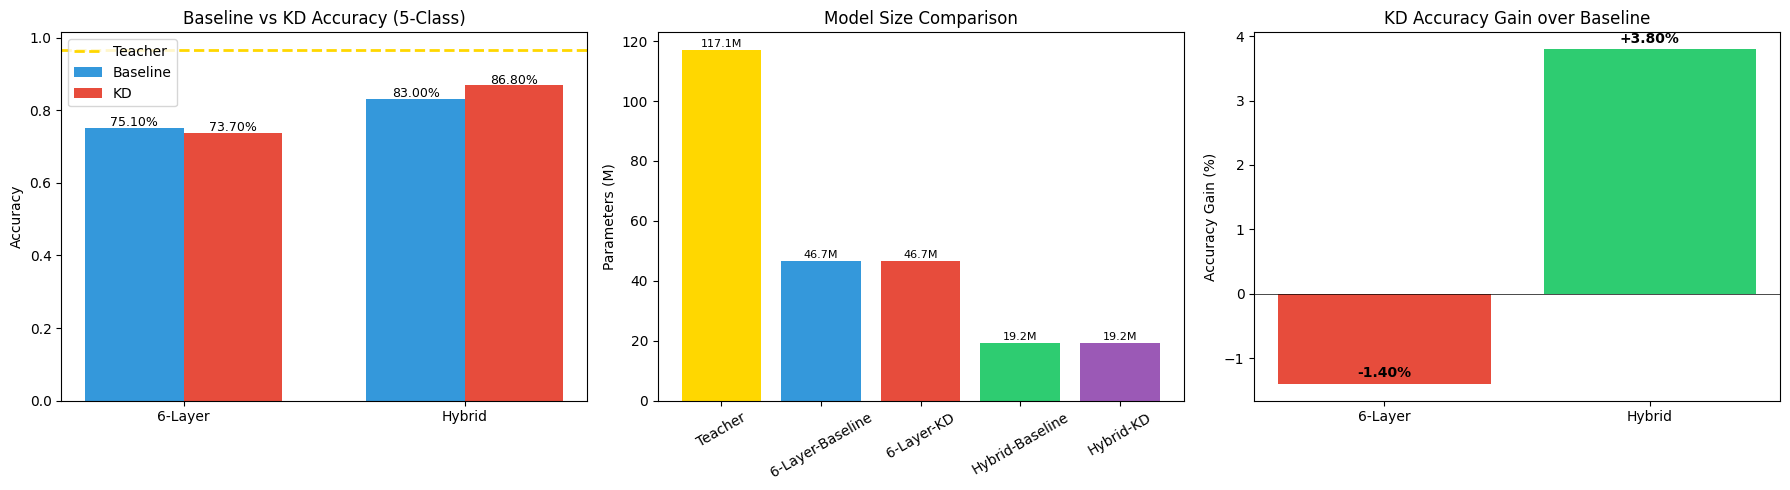

Chart saved to /kaggle/working/multiclass_kd_results.png

DARK KNOWLEDGE ANALYSIS
Average soft label entropy (T=3.0): 1.515 bits
Average hard label entropy (T=1):   0.067 bits
Max possible entropy (log2(5)): 2.322 bits
Binary case max entropy (log2(2)): 1.000 bits
Dark knowledge capacity ratio: 2.3x more informative


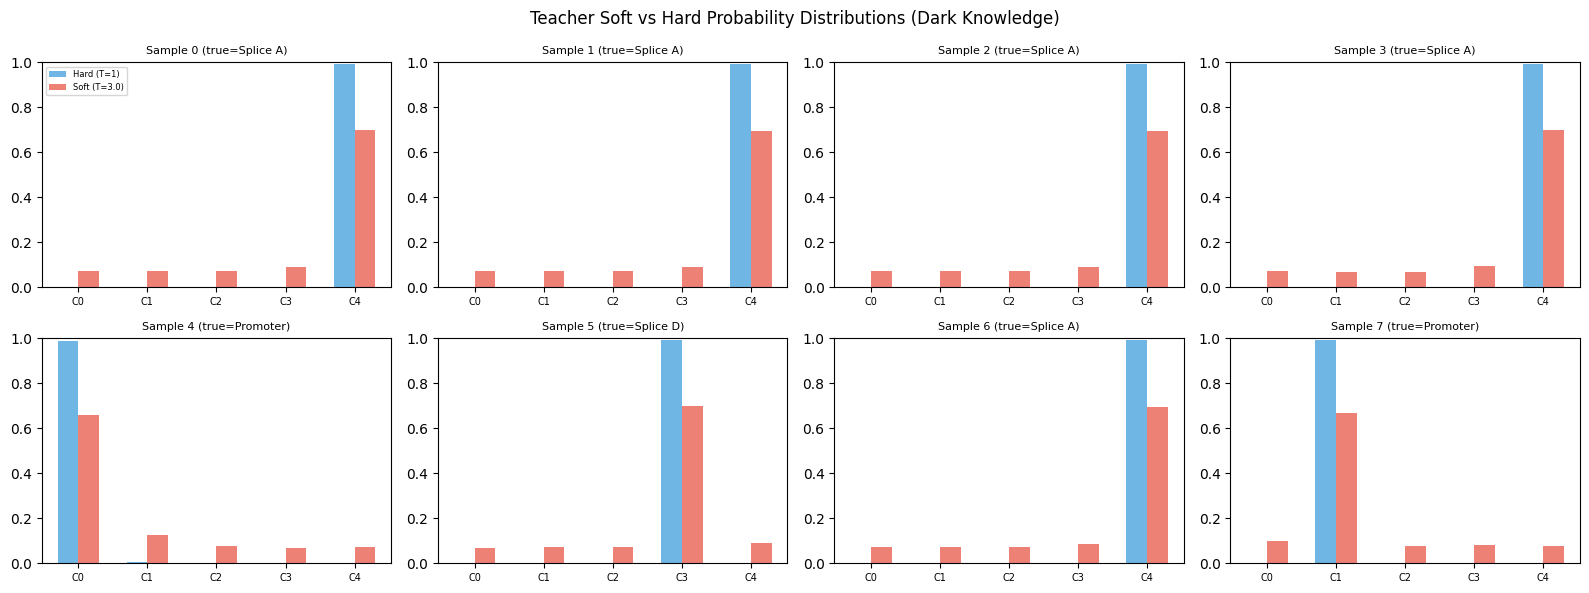

Results saved to /kaggle/working/multiclass_kd_results.json


In [7]:
import matplotlib.pyplot as plt

# ===== RESULTS TABLE =====
print("="*90)
print("MULTI-CLASS KNOWLEDGE DISTILLATION RESULTS")
print("="*90)
print(f"{'Model':<22} {'Accuracy':>10} {'F1-macro':>10} {'Params':>12} {'Time':>8}")
print("-"*90)

# Teacher
print(f"{'Teacher (DNABERT-2)':<22} {teacher_metrics['eval_accuracy']:>9.2%} {teacher_metrics['eval_f1_macro']:>10.4f} {teacher_params/1e6:>10.1f}M {'--':>8}")
print("-"*90)

for name, res in all_results.items():
    print(f"{name:<22} {res['accuracy']:>9.2%} {res['f1_macro']:>10.4f} {res['params']/1e6:>10.1f}M {res['train_time_min']:>6.1f}m")
print("="*90)

# ===== KD GAIN ANALYSIS =====
print("\nKNOWLEDGE DISTILLATION GAIN:")
for arch in ["6-Layer", "Hybrid"]:
    bl_acc = all_results[f"{arch}-Baseline"]["accuracy"]
    kd_acc = all_results[f"{arch}-KD"]["accuracy"]
    gain = kd_acc - bl_acc
    print(f"  {arch}: Baseline={bl_acc:.2%}, KD={kd_acc:.2%}, Gain={gain:+.2%}")

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Grouped bars: Baseline vs KD
archs = ["6-Layer", "Hybrid"]
x = np.arange(len(archs))
bar_width = 0.35
bl_accs = [all_results[f"{a}-Baseline"]["accuracy"] for a in archs]
kd_accs = [all_results[f"{a}-KD"]["accuracy"] for a in archs]

bars1 = axes[0].bar(x - bar_width/2, bl_accs, bar_width, label="Baseline", color="#3498db")
bars2 = axes[0].bar(x + bar_width/2, kd_accs, bar_width, label="KD", color="#e74c3c")
axes[0].axhline(y=teacher_metrics['eval_accuracy'], color="gold", linestyle="--", linewidth=2, label="Teacher")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline vs KD Accuracy (5-Class)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(archs)
axes[0].legend()
for bar, val in zip(bars1, bl_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.2%}", ha="center", fontsize=9)
for bar, val in zip(bars2, kd_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.2%}", ha="center", fontsize=9)

# 2. Model size comparison
all_names = ["Teacher"] + list(all_results.keys())
all_params_m = [teacher_params/1e6] + [all_results[n]["params"]/1e6 for n in all_results]
colors = ["gold", "#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
bars3 = axes[1].bar(all_names, all_params_m, color=colors)
axes[1].set_ylabel("Parameters (M)")
axes[1].set_title("Model Size Comparison")
axes[1].tick_params(axis='x', rotation=30)
for bar, p in zip(bars3, all_params_m):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{p:.1f}M", ha="center", fontsize=8)

# 3. KD gain bar chart
gains = [all_results[f"{a}-KD"]["accuracy"] - all_results[f"{a}-Baseline"]["accuracy"] for a in archs]
gain_colors = ["#2ecc71" if g > 0 else "#e74c3c" for g in gains]
bars4 = axes[2].bar(archs, [g * 100 for g in gains], color=gain_colors)
axes[2].set_ylabel("Accuracy Gain (%)")
axes[2].set_title("KD Accuracy Gain over Baseline")
axes[2].axhline(y=0, color="black", linewidth=0.5)
for bar, g in zip(bars4, gains):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{g:+.2%}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/multiclass_kd_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to /kaggle/working/multiclass_kd_results.png")

# ===== DARK KNOWLEDGE VISUALIZATION =====
print("\n" + "="*60)
print("DARK KNOWLEDGE ANALYSIS")
print("="*60)

# Run teacher on a test batch at T=3.0
teacher_model.to(device)
test_batch_size = 8
test_batch = {k: eval_dataset[k][:test_batch_size].to(device) for k in ["input_ids", "attention_mask"]}

with torch.no_grad():
    teacher_out = teacher_model(**test_batch)
    soft_probs = F.softmax(teacher_out.logits / TEMPERATURE, dim=-1).cpu().numpy()
    hard_probs = F.softmax(teacher_out.logits, dim=-1).cpu().numpy()

# Compute entropy of soft labels
soft_entropy = -np.sum(soft_probs * np.log2(soft_probs + 1e-10), axis=-1)
hard_entropy = -np.sum(hard_probs * np.log2(hard_probs + 1e-10), axis=-1)

print(f"Average soft label entropy (T={TEMPERATURE}): {np.mean(soft_entropy):.3f} bits")
print(f"Average hard label entropy (T=1):   {np.mean(hard_entropy):.3f} bits")
print(f"Max possible entropy (log2({NUM_CLASSES})): {np.log2(NUM_CLASSES):.3f} bits")
print(f"Binary case max entropy (log2(2)): {np.log2(2):.3f} bits")
print(f"Dark knowledge capacity ratio: {np.log2(NUM_CLASSES)/np.log2(2):.1f}x more informative")

# Plot soft probability distributions for a few samples
fig, axes2 = plt.subplots(2, 4, figsize=(16, 6))
for i in range(min(test_batch_size, 8)):
    ax = axes2[i // 4][i % 4]
    true_label = eval_dataset["labels"][i].item()
    x_pos = np.arange(NUM_CLASSES)
    ax.bar(x_pos - 0.15, hard_probs[i], 0.3, label="Hard (T=1)", color="#3498db", alpha=0.7)
    ax.bar(x_pos + 0.15, soft_probs[i], 0.3, label=f"Soft (T={TEMPERATURE})", color="#e74c3c", alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"C{j}" for j in range(NUM_CLASSES)], fontsize=7)
    ax.set_title(f"Sample {i} (true={CLASS_NAMES[true_label][:8]})", fontsize=8)
    ax.set_ylim(0, 1.0)
    if i == 0:
        ax.legend(fontsize=6)

plt.suptitle("Teacher Soft vs Hard Probability Distributions (Dark Knowledge)", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/multiclass_dark_knowledge.png", dpi=150, bbox_inches="tight")
plt.show()

# Move teacher back to CPU to free GPU memory
teacher_model.cpu()
gc.collect()
torch.cuda.empty_cache()

# ===== SAVE RESULTS JSON =====
results_json = {
    "teacher_accuracy": teacher_metrics["eval_accuracy"],
    "teacher_f1_macro": teacher_metrics["eval_f1_macro"],
    "teacher_params": teacher_params,
    "students": all_results,
    "dark_knowledge": {
        "avg_soft_entropy": float(np.mean(soft_entropy)),
        "avg_hard_entropy": float(np.mean(hard_entropy)),
        "max_entropy_5class": float(np.log2(NUM_CLASSES)),
        "max_entropy_binary": float(np.log2(2)),
    },
}
with open("/kaggle/working/multiclass_kd_results.json", "w") as f:
    json.dump(results_json, f, indent=2)
print("Results saved to /kaggle/working/multiclass_kd_results.json")